<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/08_mitigation_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
Cloning into '/content/deep-space-interference-ml'...
remote: Enumerating objects: 283, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 283 (delta 3), reused 7 (delta 1), pack-reused 266 (from 1)
Receiving objects: 100% (283/283), 9.77 MiB | 32.28 MiB/s, done.
Resolving deltas: 100% (149/149), done.
/content/deep-space-interference-ml
Already up to date.


In [2]:
# Cell 2 (updated) — denoising-only training data, N_SYMBOLS=256 per BASE-PAPER FACT
import numpy as np
import torch
from src.channel import SignalConfig, generate_soi, generate_noise
from src.model import MitigationAutoencoder, complex_to_channels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = SignalConfig(fd_max=0.0)
rng = np.random.default_rng(42)

N_SYMBOLS = 256  # BASE-PAPER FACT: paper's stated window for the denoising-only AE
SNR_RANGE_TRAIN = (-15, 30)

def make_denoising_pair(cfg, n_symbols, snr_range, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    snr_db = rng.uniform(*snr_range)
    rho_snr = 10 ** (snr_db / 10)
    x = s + w / np.sqrt(rho_snr)
    return complex_to_channels(x).astype(np.float32), complex_to_channels(s).astype(np.float32)

M_TRAIN, M_VAL = 3000, 750
X_train = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, rng)[0] for _ in range(M_TRAIN)])
Y_train = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, rng)[1] for _ in range(M_TRAIN)])
X_val = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, rng)[0] for _ in range(M_VAL)])
Y_val = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, rng)[1] for _ in range(M_VAL)])
print("X_train:", X_train.shape)  # expect (3000, 2, 2048) -- 256 symbols x 8 NSPS

identity_mse_train = np.mean((X_train - Y_train) ** 2)
print(f"Identity baseline MSE (train): {identity_mse_train:.5f}")

X_train: (3000, 2, 2048)
Identity baseline MSE (train): 2.42506


In [3]:
# Cell 3 — DEBUG LADDER
model = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
tiny_x = torch.tensor(X_train[:8], device=device)
out = model(tiny_x)
print("TEST 1: output shape", out.shape, " input shape", tiny_x.shape)
assert out.shape == tiny_x.shape

tiny_y = torch.tensor(Y_train[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=3e-5)  # BASE-PAPER FACT (mitigation AE lr)
loss = loss_fn(out, tiny_y); loss.backward(); opt.step(); opt.zero_grad()
print(f"TEST 2: one grad step OK, loss={loss.item():.4f}")

small_x = torch.tensor(X_train[:200], device=device)
small_y = torch.tensor(Y_train[:200], device=device)
losses = []
for _ in range(20):  # more steps than before -- lr=3e-5 is much smaller, needs more steps to visibly move
    opt.zero_grad()
    out = model(small_x)
    loss = loss_fn(out, small_y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print("TEST 3/4 losses:", [f"{l:.4f}" for l in losses])
assert losses[-1] < losses[0], "Loss did not decrease -- stop, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8, 2, 2048])  input shape torch.Size([8, 2, 2048])
TEST 2: one grad step OK, loss=2.6912
TEST 3/4 losses: ['2.1985', '2.1918', '2.1856', '2.1802', '2.1754', '2.1712', '2.1673', '2.1637', '2.1603', '2.1570', '2.1538', '2.1506', '2.1474', '2.1441', '2.1408', '2.1374', '2.1339', '2.1304', '2.1268', '2.1231']
Debug ladder PASSED.


In [4]:
identity_mse_train = np.mean((X_train - Y_train) ** 2)
identity_mse_val = np.mean((X_val - Y_val) ** 2)
print(f"Identity baseline MSE (train): {identity_mse_train:.5f}")
print(f"Identity baseline MSE (val):   {identity_mse_val:.5f}")

Identity baseline MSE (train): 2.42506
Identity baseline MSE (val):   2.45443


In [5]:
# Cell 3c — confirm which version of forward() is ACTUALLY loaded right now
import inspect

src = inspect.getsource(MitigationAutoencoder.forward)
print(src)
print("---")
print("Has residual connection ('+ x'):", "+ x" in src.replace(" ", ""))

    def forward(self, x):
        h = self.first_conv(x)
        for layer in self.encoder:
            h = layer(h)
        for layer in self.decoder:
            h = layer(h)
        out = self.final_conv(h)
        if out.shape[-1] != x.shape[-1]:
            min_len = min(out.shape[-1], x.shape[-1])
            out = out[..., :min_len]
            x = x[..., :min_len]
        return out + x

---
Has residual connection ('+ x'): False


Epoch 1/100  train_loss=2.35511  val_loss=2.29894
Epoch 5/100  train_loss=1.90431  val_loss=1.91209
Epoch 10/100  train_loss=1.79732  val_loss=1.82602
Epoch 15/100  train_loss=1.73360  val_loss=1.75688
Epoch 20/100  train_loss=1.64764  val_loss=1.67567
Epoch 25/100  train_loss=1.55007  val_loss=1.59894
Epoch 30/100  train_loss=1.45108  val_loss=1.46840
Epoch 35/100  train_loss=1.36873  val_loss=1.37495
Epoch 40/100  train_loss=1.28790  val_loss=1.29209
Epoch 45/100  train_loss=1.21554  val_loss=1.22498
Epoch 50/100  train_loss=1.15366  val_loss=1.15723
Epoch 55/100  train_loss=1.09729  val_loss=1.10137
Epoch 60/100  train_loss=1.04789  val_loss=1.04905
Epoch 65/100  train_loss=0.99780  val_loss=1.00602
Epoch 70/100  train_loss=0.95259  val_loss=0.95222
Epoch 75/100  train_loss=0.89818  val_loss=0.89822
Epoch 80/100  train_loss=0.86131  val_loss=0.85798
Epoch 85/100  train_loss=0.82271  val_loss=0.83359
Epoch 90/100  train_loss=0.79397  val_loss=0.80917
Epoch 95/100  train_loss=0.76732 

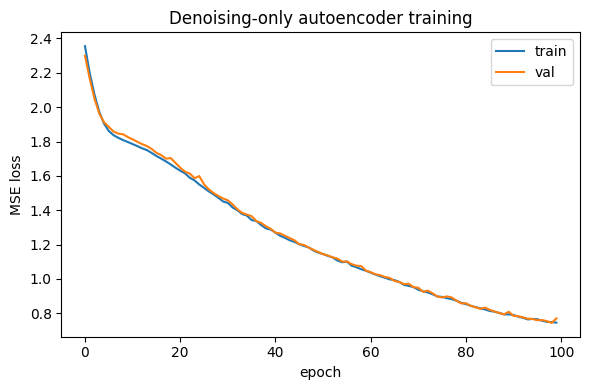

In [6]:
# Cell 4 — full training, denoising-only (SOI+noise, no interference)
def train_mitigation_ae(model, X_train, Y_train, X_val, Y_val, device,
                          epochs=100, batch_size=64, lr=3e-5, patience=10, seed=42):
    torch.manual_seed(seed)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    Xt = torch.tensor(X_train, device=device)
    Yt = torch.tensor(Y_train, device=device)
    Xv = torch.tensor(X_val, device=device)
    Yv = torch.tensor(Y_val, device=device)

    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, patience_ct = float("inf"), None, 0
    n = Xt.shape[0]

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        ep_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            out = model(Xt[idx])
            loss = loss_fn(out, Yt[idx])
            loss.backward(); opt.step()
            ep_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), Yv).item()

        train_loss = float(np.mean(ep_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}")

        if val_loss < best_val:
            best_val, best_state, patience_ct = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return model, history

model_denoise = MitigationAutoencoder(n_stages=2, n_hidden=32)
model_denoise, history_denoise = train_mitigation_ae(model_denoise, X_train, Y_train, X_val, Y_val, device)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history_denoise["train_loss"], label="train")
plt.plot(history_denoise["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.title("Denoising-only autoencoder training")
plt.tight_layout()
plt.savefig("figures/mitigation_ae_denoise_only_training.png", dpi=150)
plt.show()

import os
os.makedirs("checkpoints", exist_ok=True)
torch.save(model_denoise.state_dict(), "checkpoints/mitigation_ae_denoise_only.pt")

In [7]:
# Cell 4b — diagnostic retrain at a much larger LR, to test if lr=3e-5 was simply too small to escape the trivial solution
model_denoise_lr_test = MitigationAutoencoder(n_stages=2, n_hidden=32)
model_denoise_lr_test, history_lr_test = train_mitigation_ae(
    model_denoise_lr_test, X_train, Y_train, X_val, Y_val, device,
    epochs=100, lr=1e-3, patience=15  # OUR diagnostic: 30x paper's stated lr
)
print(f"Final val_loss at lr=1e-3: {history_lr_test['val_loss'][-1]:.5f}  (vs identity baseline {identity_mse_train:.5f}, vs 0.5 'output-zero' floor)")

Epoch 1/100  train_loss=2.04619  val_loss=1.88630
Epoch 5/100  train_loss=0.92576  val_loss=0.84945
Epoch 10/100  train_loss=0.54924  val_loss=0.54309
Epoch 15/100  train_loss=0.53848  val_loss=0.53987
Epoch 20/100  train_loss=0.53030  val_loss=0.53591
Epoch 25/100  train_loss=0.52186  val_loss=0.54844
Epoch 30/100  train_loss=0.52488  val_loss=0.52691
Epoch 35/100  train_loss=0.52856  val_loss=0.52244
Epoch 40/100  train_loss=0.53728  val_loss=0.52734
Epoch 45/100  train_loss=0.52466  val_loss=0.54964
Early stopping at epoch 49
Final val_loss at lr=1e-3: 0.55882  (vs identity baseline 2.42506, vs 0.5 'output-zero' floor)


Eb/N0=0dB  interference=0.3340  mitigated=0.4346  clean=0.1577  theoretical=0.0786
Eb/N0=1dB  interference=0.3242  mitigated=0.4509  clean=0.1306  theoretical=0.0563
Eb/N0=2dB  interference=0.3283  mitigated=0.4568  clean=0.1029  theoretical=0.0375
Eb/N0=3dB  interference=0.3180  mitigated=0.4648  clean=0.0806  theoretical=0.0229
Eb/N0=4dB  interference=0.3131  mitigated=0.4625  clean=0.0564  theoretical=0.0125
Eb/N0=5dB  interference=0.3178  mitigated=0.4608  clean=0.0388  theoretical=0.0060
Eb/N0=6dB  interference=0.3071  mitigated=0.4589  clean=0.0236  theoretical=0.0024


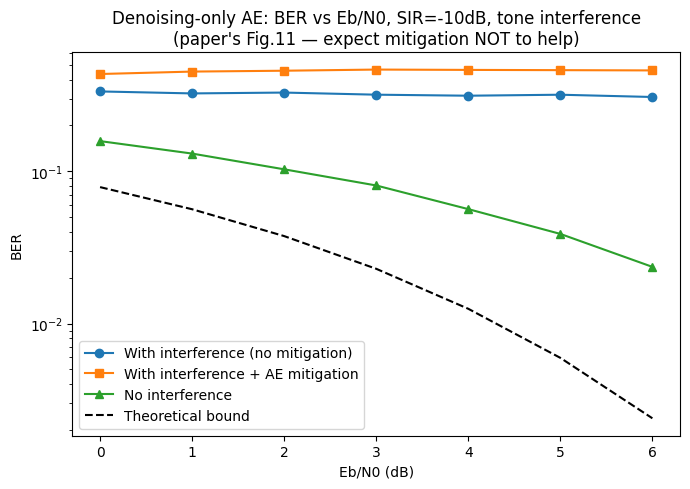

In [8]:
# Cell 5 — BER test: does DENOISING-ONLY autoencoder reduce BER against tone interference? (Fig.11/12)
from src.channel import mix_signal
from src.evaluate import matched_filter_ber, theoretical_ber

def ae_denoise(x_complex, model, device):
    channels = complex_to_channels(x_complex).astype(np.float32)
    with torch.no_grad():
        inp = torch.tensor(channels, device=device).unsqueeze(0)
        out = model(inp).squeeze(0).cpu().numpy()
    return out[0] + 1j*out[1]

SIR_DB_TEST = -10.0  # BASE-PAPER FACT (Fig.11 uses SIR=-10dB)
EBN0_RANGE = [0, 1, 2, 3, 4, 5, 6]  # BASE-PAPER FACT (Fig.11's x-axis range)
N_TRIALS = 300

ber_results = []
for ebn0_db in EBN0_RANGE:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)  # invert our OUR ASSUMPTION Eb/N0<->SNR relationship

    ber_interference, ber_mitigated, ber_clean = [], [], []
    for _ in range(N_TRIALS):
        d = mix_signal(cfg, N_SYMBOLS, rng, interference_type="tone", contamination=1.0,
                        sir_db_range=(SIR_DB_TEST, SIR_DB_TEST), snr_db_range=(snr_db, snr_db),
                        apply_shift=False)
        x, bits, fd, phi_m, k_shift = d["x"], d["bits"], d["fd"], d["phi_m"], d["k_shift"]

        ber_interference.append(matched_filter_ber(x, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        x_mitigated = ae_denoise(x, model_denoise, device)
        ber_mitigated.append(matched_filter_ber(x_mitigated, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        d_clean = mix_signal(cfg, N_SYMBOLS, rng, interference_type="tone", contamination=0.0,
                              snr_db_range=(snr_db, snr_db), apply_shift=False)
        ber_clean.append(matched_filter_ber(d_clean["x"], d_clean["bits"], cfg, N_SYMBOLS,
                                              d_clean["fd"], d_clean["phi_m"], d_clean["k_shift"]))

    ber_results.append({
        "ebn0_db": ebn0_db,
        "ber_with_interference": np.mean(ber_interference),
        "ber_mitigated": np.mean(ber_mitigated),
        "ber_no_interference": np.mean(ber_clean),
        "ber_theoretical": theoretical_ber(ebn0_db),
    })
    print(f"Eb/N0={ebn0_db}dB  interference={np.mean(ber_interference):.4f}  "
          f"mitigated={np.mean(ber_mitigated):.4f}  clean={np.mean(ber_clean):.4f}  "
          f"theoretical={theoretical_ber(ebn0_db):.4f}")

import pandas as pd
ber_df = pd.DataFrame(ber_results)
ber_df.to_csv("results/step8_denoise_only_ber.csv", index=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_with_interference"], marker='o', label="With interference (no mitigation)")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_mitigated"], marker='s', label="With interference + AE mitigation")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_no_interference"], marker='^', label="No interference")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_theoretical"], linestyle='--', color='black', label="Theoretical bound")
plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER")
plt.title("Denoising-only AE: BER vs Eb/N0, SIR=-10dB, tone interference\n(paper's Fig.11 — expect mitigation NOT to help)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/step8_denoise_only_ber.png", dpi=150)
plt.show()

In [9]:
# Cell 5b — diagnostic: does the AE fail even WITHOUT interference, at this low-SNR test range?
# If YES -> SNR mismatch (trained at 15dB, tested at -9 to -3dB) is the dominant cause
# If NO (works fine here) -> the failure is specifically about never having seen interference

# Cell 5b (re-run with the FIXED, non-collapsed model_denoise)
ber_clean_only_check = []
for ebn0_db in EBN0_RANGE:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)
    ber_raw, ber_mit = [], []
    for _ in range(N_TRIALS):
        d = mix_signal(cfg, N_SYMBOLS, rng, interference_type=None, contamination=0.0,
                        snr_db_range=(snr_db, snr_db), apply_shift=False)
        x, bits, fd, phi_m, k_shift = d["x"], d["bits"], d["fd"], d["phi_m"], d["k_shift"]
        ber_raw.append(matched_filter_ber(x, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))
        x_mit = ae_denoise(x, model_denoise, device)
        ber_mit.append(matched_filter_ber(x_mit, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))
    ber_clean_only_check.append({"ebn0_db": ebn0_db, "ber_no_ae": np.mean(ber_raw), "ber_with_ae": np.mean(ber_mit)})
    print(f"Eb/N0={ebn0_db}dB (NO interference)  raw={np.mean(ber_raw):.4f}  AE-processed={np.mean(ber_mit):.4f}")

Eb/N0=0dB (NO interference)  raw=0.1592  AE-processed=0.5552
Eb/N0=1dB (NO interference)  raw=0.1309  AE-processed=0.5467
Eb/N0=2dB (NO interference)  raw=0.1053  AE-processed=0.5252
Eb/N0=3dB (NO interference)  raw=0.0776  AE-processed=0.5091
Eb/N0=4dB (NO interference)  raw=0.0570  AE-processed=0.4851
Eb/N0=5dB (NO interference)  raw=0.0381  AE-processed=0.4713
Eb/N0=6dB (NO interference)  raw=0.0226  AE-processed=0.4601


In [10]:
# Cell 5c — direct check: is the model's raw output collapsed near zero?
sample_x = torch.tensor(X_val[:20], device=device)
with torch.no_grad():
    sample_out = model_denoise(sample_x)

print("Model output — mean abs:", sample_out.abs().mean().item())
print("Model output — std:", sample_out.std().item())
print("Target (clean SOI) — mean abs:", torch.tensor(Y_val[:20]).abs().mean().item())
print("Target (clean SOI) — std:", torch.tensor(Y_val[:20]).std().item())

Model output — mean abs: 0.34828054904937744
Model output — std: 0.647879958152771
Target (clean SOI) — mean abs: 0.6535919308662415
Target (clean SOI) — std: 0.7054399847984314


In [11]:
!ls -la checkpoints/mitigation_ae_denoise_only.pt results/step8_denoise_only_ber.csv figures/step8_denoise_only_ber.png

-rw-r--r-- 1 root root 1175829 Sep  1 04:12 checkpoints/mitigation_ae_denoise_only.pt
-rw-r--r-- 1 root root   78938 Sep  1 04:19 figures/step8_denoise_only_ber.png
-rw-r--r-- 1 root root     647 Sep  1 04:19 results/step8_denoise_only_ber.csv


In [12]:
!git config pull.rebase false
!git pull --no-edit

Already up to date.


In [28]:
!git add checkpoints/mitigation_ae_denoise_only.pt results/step8_denoise_only_ber.csv figures/step8_denoise_only_ber.png notebooks/08_mitigation_autoencoder.ipynb src/model.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   checkpoints/mitigation_ae_denoise_only.pt
	new file:   figures/step8_denoise_only_ber.png
	new file:   results/step8_denoise_only_ber.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	figures/mitigation_ae_denoise_only_training.png



In [13]:
!git add figures/mitigation_ae_denoise_only_training.png
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   figures/mitigation_ae_denoise_only_training.png

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   checkpoints/mitigation_ae_denoise_only.pt
	modified:   figures/step8_denoise_only_ber.png
	modified:   results/step8_denoise_only_ber.csv



In [14]:
!git commit -m "Step 8a: denoising-only mitigation AE (mode-collapse fix, N_SYMBOLS=256, BER results)"
!git push


[main c03d653] Step 8a: denoising-only mitigation AE (mode-collapse fix, N_SYMBOLS=256, BER results)
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite figures/mitigation_ae_denoise_only_training.png (99%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 41.16 KiB | 13.72 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   f7e8e4f..c03d653  main -> main


In [15]:
# Cell 6 — interference-aware training data (tone, matching paper's Fig.13/14 setup)
N_SYMBOLS_MITIGATION = 1024  # BASE-PAPER FACT: paper's stated window for interference-aware training
SIR_RANGE_TRAIN = (-10, 30)  # BASE-PAPER FACT

def make_mitigation_pair(cfg, n_symbols, snr_range, sir_range, interference_type, rng):
    d = mix_signal(cfg, n_symbols, rng, interference_type=interference_type,
                    contamination=0.5, sir_db_range=sir_range, snr_db_range=snr_range, apply_shift=False)
    return complex_to_channels(d["x"]).astype(np.float32), complex_to_channels(d["s"]).astype(np.float32)

M_TRAIN_MIT, M_VAL_MIT = 1500, 400  # smaller than before: 1024 symbols = 16x more compute/sample than 64
X_train_mit = np.stack([make_mitigation_pair(cfg, N_SYMBOLS_MITIGATION, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, "tone", rng)[0] for _ in range(M_TRAIN_MIT)])
Y_train_mit = np.stack([make_mitigation_pair(cfg, N_SYMBOLS_MITIGATION, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, "tone", rng)[1] for _ in range(M_TRAIN_MIT)])
X_val_mit = np.stack([make_mitigation_pair(cfg, N_SYMBOLS_MITIGATION, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, "tone", rng)[0] for _ in range(M_VAL_MIT)])
Y_val_mit = np.stack([make_mitigation_pair(cfg, N_SYMBOLS_MITIGATION, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, "tone", rng)[1] for _ in range(M_VAL_MIT)])
print("X_train_mit:", X_train_mit.shape)  # expect (1500, 2, 8192) -- 1024 symbols x 8 NSPS

identity_mse_mit = np.mean((X_train_mit - Y_train_mit) ** 2)
print(f"Identity baseline MSE (train): {identity_mse_mit:.5f}")

X_train_mit: (1500, 2, 8192)
Identity baseline MSE (train): 2.79393


In [16]:
# Cell 7 — DEBUG LADDER (mandatory, same discipline as always — especially given Step 8a's lesson)
model_mit_tone = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
tiny_x = torch.tensor(X_train_mit[:8], device=device)
out = model_mit_tone(tiny_x)
print("TEST 1: output shape", out.shape, " input shape", tiny_x.shape)
assert out.shape == tiny_x.shape

tiny_y = torch.tensor(Y_train_mit[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model_mit_tone.parameters(), lr=3e-5)
loss = loss_fn(out, tiny_y); loss.backward(); opt.step(); opt.zero_grad()
print(f"TEST 2: one grad step OK, loss={loss.item():.4f}  (expect near identity baseline {identity_mse_mit:.4f}, confirming residual connection active)")

small_x = torch.tensor(X_train_mit[:200], device=device)
small_y = torch.tensor(Y_train_mit[:200], device=device)
losses = []
for _ in range(20):
    opt.zero_grad()
    out = model_mit_tone(small_x)
    loss = loss_fn(out, small_y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print("TEST 3/4 losses:", [f"{l:.4f}" for l in losses])
assert losses[-1] < losses[0], "Loss did not decrease -- stop, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8, 2, 8192])  input shape torch.Size([8, 2, 8192])
TEST 2: one grad step OK, loss=3.7297  (expect near identity baseline 2.7939, confirming residual connection active)
TEST 3/4 losses: ['3.1046', '3.0992', '3.0939', '3.0888', '3.0840', '3.0797', '3.0756', '3.0719', '3.0684', '3.0650', '3.0618', '3.0586', '3.0554', '3.0523', '3.0492', '3.0461', '3.0429', '3.0398', '3.0366', '3.0334']
Debug ladder PASSED.


Epoch 1/100  train_loss=2.68747  val_loss=2.53553
Epoch 5/100  train_loss=2.17768  val_loss=2.07220
Epoch 10/100  train_loss=1.95466  val_loss=1.88068
Epoch 15/100  train_loss=1.79497  val_loss=1.74926
Epoch 20/100  train_loss=1.69489  val_loss=1.64474
Epoch 25/100  train_loss=1.63464  val_loss=1.58673
Epoch 30/100  train_loss=1.57467  val_loss=1.53526
Epoch 35/100  train_loss=1.51439  val_loss=1.45522
Epoch 40/100  train_loss=1.43253  val_loss=1.38690
Epoch 45/100  train_loss=1.36174  val_loss=1.31926
Epoch 50/100  train_loss=1.29743  val_loss=1.26095
Epoch 55/100  train_loss=1.22238  val_loss=1.19175
Epoch 60/100  train_loss=1.16524  val_loss=1.12867
Epoch 65/100  train_loss=1.10737  val_loss=1.08889
Epoch 70/100  train_loss=1.06011  val_loss=1.03168
Epoch 75/100  train_loss=1.01460  val_loss=0.98565
Epoch 80/100  train_loss=0.97215  val_loss=0.96407
Epoch 85/100  train_loss=0.93963  val_loss=0.91542
Epoch 90/100  train_loss=0.90688  val_loss=0.88934
Epoch 95/100  train_loss=0.87321 

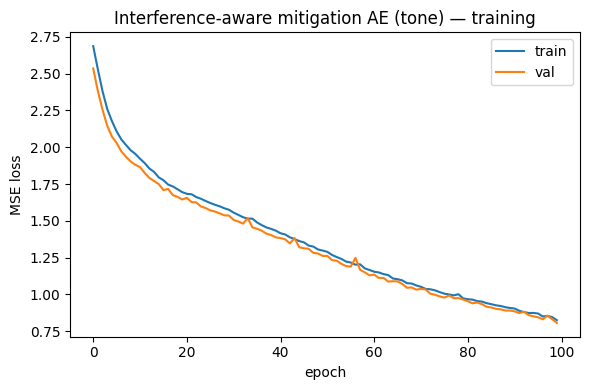

Final val_loss: 0.80552  (vs identity baseline 2.79393)


In [17]:
# Cell 8 — full training: interference-aware mitigation AE (tone)
model_mit_tone, history_mit_tone = train_mitigation_ae(
    model_mit_tone, X_train_mit, Y_train_mit, X_val_mit, Y_val_mit, device,
    epochs=100, batch_size=32, lr=3e-5, patience=15  # smaller batch given much longer sequences
)

plt.figure(figsize=(6,4))
plt.plot(history_mit_tone["train_loss"], label="train")
plt.plot(history_mit_tone["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.title("Interference-aware mitigation AE (tone) — training")
plt.tight_layout()
plt.savefig("figures/mitigation_ae_tone_training.png", dpi=150)
plt.show()

torch.save(model_mit_tone.state_dict(), "checkpoints/mitigation_ae_tone.pt")
print(f"Final val_loss: {history_mit_tone['val_loss'][-1]:.5f}  (vs identity baseline {identity_mse_mit:.5f})")

Eb/N0=0dB  interference=0.3392  mitigated=0.4487  clean=0.1596  theoretical=0.0786
Eb/N0=1dB  interference=0.3174  mitigated=0.4673  clean=0.1316  theoretical=0.0563
Eb/N0=2dB  interference=0.3199  mitigated=0.4813  clean=0.1044  theoretical=0.0375
Eb/N0=3dB  interference=0.3352  mitigated=0.4935  clean=0.0794  theoretical=0.0229
Eb/N0=4dB  interference=0.3226  mitigated=0.4964  clean=0.0561  theoretical=0.0125
Eb/N0=5dB  interference=0.3175  mitigated=0.5071  clean=0.0372  theoretical=0.0060
Eb/N0=6dB  interference=0.3043  mitigated=0.5013  clean=0.0232  theoretical=0.0024


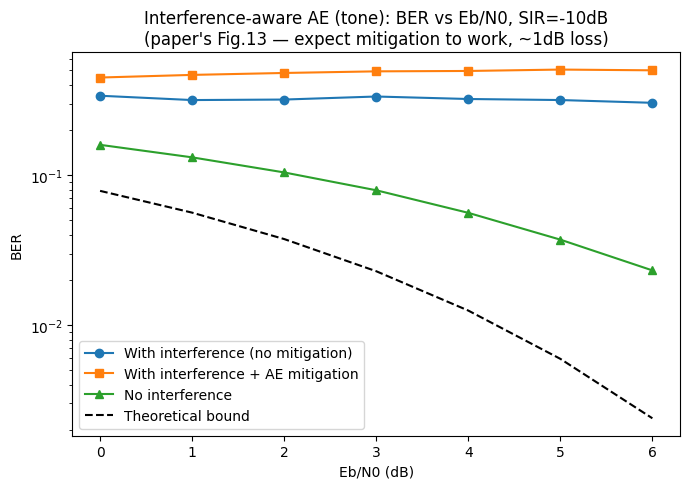

In [18]:
# Cell 9 — BER test: interference-aware AE (tone), full window N_SYMBOLS_MITIGATION=1024
SIR_DB_TEST = -10.0  # BASE-PAPER FACT (Fig.13 uses SIR=-10dB)
EBN0_RANGE = [0, 1, 2, 3, 4, 5, 6]  # BASE-PAPER FACT
N_TRIALS_MIT = 100  # fewer trials given the much heavier per-sample cost at 1024 symbols

ber_results_mit = []
for ebn0_db in EBN0_RANGE:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)

    ber_interference, ber_mitigated, ber_clean = [], [], []
    for _ in range(N_TRIALS_MIT):
        d = mix_signal(cfg, N_SYMBOLS_MITIGATION, rng, interference_type="tone", contamination=1.0,
                        sir_db_range=(SIR_DB_TEST, SIR_DB_TEST), snr_db_range=(snr_db, snr_db), apply_shift=False)
        x, bits, fd, phi_m, k_shift = d["x"], d["bits"], d["fd"], d["phi_m"], d["k_shift"]

        ber_interference.append(matched_filter_ber(x, bits, cfg, N_SYMBOLS_MITIGATION, fd, phi_m, k_shift))

        x_mitigated = ae_denoise(x, model_mit_tone, device)
        ber_mitigated.append(matched_filter_ber(x_mitigated, bits, cfg, N_SYMBOLS_MITIGATION, fd, phi_m, k_shift))

        d_clean = mix_signal(cfg, N_SYMBOLS_MITIGATION, rng, interference_type="tone", contamination=0.0,
                              snr_db_range=(snr_db, snr_db), apply_shift=False)
        ber_clean.append(matched_filter_ber(d_clean["x"], d_clean["bits"], cfg, N_SYMBOLS_MITIGATION,
                                              d_clean["fd"], d_clean["phi_m"], d_clean["k_shift"]))

    ber_results_mit.append({
        "ebn0_db": ebn0_db,
        "ber_with_interference": np.mean(ber_interference),
        "ber_mitigated": np.mean(ber_mitigated),
        "ber_no_interference": np.mean(ber_clean),
        "ber_theoretical": theoretical_ber(ebn0_db),
    })
    print(f"Eb/N0={ebn0_db}dB  interference={np.mean(ber_interference):.4f}  "
          f"mitigated={np.mean(ber_mitigated):.4f}  clean={np.mean(ber_clean):.4f}  "
          f"theoretical={theoretical_ber(ebn0_db):.4f}")

ber_df_mit = pd.DataFrame(ber_results_mit)
ber_df_mit.to_csv("results/step8b_tone_mitigation_ber.csv", index=False)

plt.figure(figsize=(7,5))
plt.semilogy(ber_df_mit["ebn0_db"], ber_df_mit["ber_with_interference"], marker='o', label="With interference (no mitigation)")
plt.semilogy(ber_df_mit["ebn0_db"], ber_df_mit["ber_mitigated"], marker='s', label="With interference + AE mitigation")
plt.semilogy(ber_df_mit["ebn0_db"], ber_df_mit["ber_no_interference"], marker='^', label="No interference")
plt.semilogy(ber_df_mit["ebn0_db"], ber_df_mit["ber_theoretical"], linestyle='--', color='black', label="Theoretical bound")
plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER")
plt.title("Interference-aware AE (tone): BER vs Eb/N0, SIR=-10dB\n(paper's Fig.13 — expect mitigation to work, ~1dB loss)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/step8b_tone_mitigation_ber.png", dpi=150)
plt.show()

In [19]:
# Cell 9b — is the AE overcorrecting at low-noise/high-Eb-N0? Check output vs. input vs. target stats directly
for ebn0_db in [0, 6]:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)
    d = mix_signal(cfg, N_SYMBOLS_MITIGATION, rng, interference_type="tone", contamination=1.0,
                    sir_db_range=(SIR_DB_TEST, SIR_DB_TEST), snr_db_range=(snr_db, snr_db), apply_shift=False)
    x_mit = ae_denoise(d["x"], model_mit_tone, device)

    mse_input_vs_target = np.mean(np.abs(d["x"] - d["s"])**2)
    mse_output_vs_target = np.mean(np.abs(x_mit - d["s"])**2)
    print(f"Eb/N0={ebn0_db}dB: MSE(input,target)={mse_input_vs_target:.4f}  MSE(AE_output,target)={mse_output_vs_target:.4f}  "
          f"-> AE {'HELPS' if mse_output_vs_target < mse_input_vs_target else 'HURTS'} reconstruction here")

Eb/N0=0dB: MSE(input,target)=17.9498  MSE(AE_output,target)=2.6211  -> AE HELPS reconstruction here
Eb/N0=6dB: MSE(input,target)=12.0811  MSE(AE_output,target)=1.7071  -> AE HELPS reconstruction here


In [20]:
!ls -la checkpoints/mitigation_ae_tone.pt results/step8b_tone_mitigation_ber.csv figures/step8b_tone_mitigation_ber.png figures/mitigation_ae_tone_training.png

-rw-r--r-- 1 root root 1175365 Sep  1 04:24 checkpoints/mitigation_ae_tone.pt
-rw-r--r-- 1 root root   53554 Sep  1 04:24 figures/mitigation_ae_tone_training.png
-rw-r--r-- 1 root root   79640 Sep  1 04:26 figures/step8b_tone_mitigation_ber.png
-rw-r--r-- 1 root root     644 Sep  1 04:26 results/step8b_tone_mitigation_ber.csv


In [21]:
!git config pull.rebase false
!git pull --no-edit

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 169.53 KiB | 7.06 MiB/s, done.
From https://github.com/Evenjlin/deep-space-interference-ml
   c03d653..a848b16  main       -> origin/main
Updating c03d653..a848b16
Fast-forward
 notebooks/08_mitigation_autoencoder.ipynb | 395 ++++++++++++++++--------------
 1 file changed, 206 insertions(+), 189 deletions(-)


In [22]:
!git add checkpoints/mitigation_ae_tone.pt results/step8b_tone_mitigation_ber.csv figures/step8b_tone_mitigation_ber.png figures/mitigation_ae_tone_training.png notebooks/08_mitigation_autoencoder.ipynb
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   checkpoints/mitigation_ae_tone.pt
	new file:   figures/mitigation_ae_tone_training.png
	new file:   figures/step8b_tone_mitigation_ber.png
	new file:   results/step8b_tone_mitigation_ber.csv

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   checkpoints/mitigation_ae_denoise_only.pt
	modified:   figures/step8_denoise_only_ber.png
	modified:   results/step8_denoise_only_ber.csv



In [23]:
!git add checkpoints/mitigation_ae_denoise_only.pt figures/step8_denoise_only_ber.png results/step8_denoise_only_ber.csv
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   checkpoints/mitigation_ae_denoise_only.pt
	new file:   checkpoints/mitigation_ae_tone.pt
	new file:   figures/mitigation_ae_tone_training.png
	modified:   figures/step8_denoise_only_ber.png
	new file:   figures/step8b_tone_mitigation_ber.png
	modified:   results/step8_denoise_only_ber.csv
	new file:   results/step8b_tone_mitigation_ber.csv



In [24]:
!git commit -m "Step 8: final Step 8a (denoising-only, N=256) and Step 8b (interference-aware tone) results together"
!git push

[main 374a6ce] Step 8: final Step 8a (denoising-only, N=256) and Step 8b (interference-aware tone) results together
 7 files changed, 16 insertions(+), 8 deletions(-)
 rewrite checkpoints/mitigation_ae_denoise_only.pt (84%)
 create mode 100644 checkpoints/mitigation_ae_tone.pt
 create mode 100644 figures/mitigation_ae_tone_training.png
 rewrite figures/step8_denoise_only_ber.png (98%)
 create mode 100644 figures/step8b_tone_mitigation_ber.png
 rewrite results/step8_denoise_only_ber.csv (79%)
 create mode 100644 results/step8b_tone_mitigation_ber.csv
Enumerating objects: 19, done.
Counting objects: 100% (19/19), done.
Delta compression using up to 2 threads
Compressing objects: 100% (12/12), done.
Writing objects: 100% (12/12), 2.24 MiB | 6.00 MiB/s, done.
Total 12 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   a848b16..374a6ce  main -> main



==================== SQUARE ====================
X_train: (1500, 2, 8192)  Identity baseline MSE: 2.7943
Sanity check -- first-pass loss: 3.7068 (expect near identity baseline 2.7943)
Epoch 1/100  train_loss=2.75586  val_loss=2.80726
Epoch 5/100  train_loss=2.23918  val_loss=2.32314
Epoch 10/100  train_loss=2.10249  val_loss=2.18900
Epoch 15/100  train_loss=2.01449  val_loss=2.09338
Epoch 20/100  train_loss=1.91038  val_loss=1.97287
Epoch 25/100  train_loss=1.78613  val_loss=1.84325
Epoch 30/100  train_loss=1.65737  val_loss=1.70633
Epoch 35/100  train_loss=1.54701  val_loss=1.57761
Epoch 40/100  train_loss=1.44244  val_loss=1.48371
Epoch 45/100  train_loss=1.34448  val_loss=1.39277
Epoch 50/100  train_loss=1.25724  val_loss=1.28552
Epoch 55/100  train_loss=1.19004  val_loss=1.21864
Epoch 60/100  train_loss=1.13926  val_loss=1.15953
Epoch 65/100  train_loss=1.08142  val_loss=1.09415
Epoch 70/100  train_loss=1.04125  val_loss=1.05591
Epoch 75/100  train_loss=0.99862  val_loss=1.01703
E

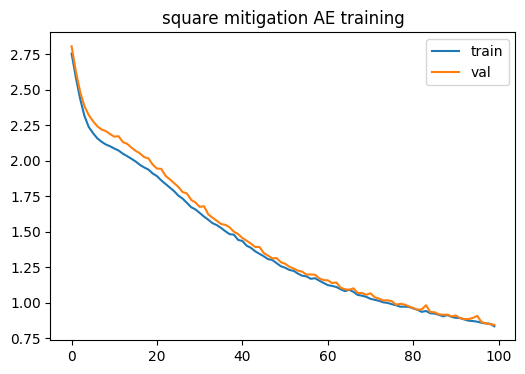

Eb/N0=0dB  interference=0.2677  mitigated=0.4175  clean=0.1591
Eb/N0=1dB  interference=0.2688  mitigated=0.4435  clean=0.1305
Eb/N0=2dB  interference=0.2647  mitigated=0.4545  clean=0.1043
Eb/N0=3dB  interference=0.2579  mitigated=0.4577  clean=0.0777
Eb/N0=4dB  interference=0.2442  mitigated=0.4654  clean=0.0566
Eb/N0=5dB  interference=0.2415  mitigated=0.4736  clean=0.0373
Eb/N0=6dB  interference=0.2241  mitigated=0.4678  clean=0.0237


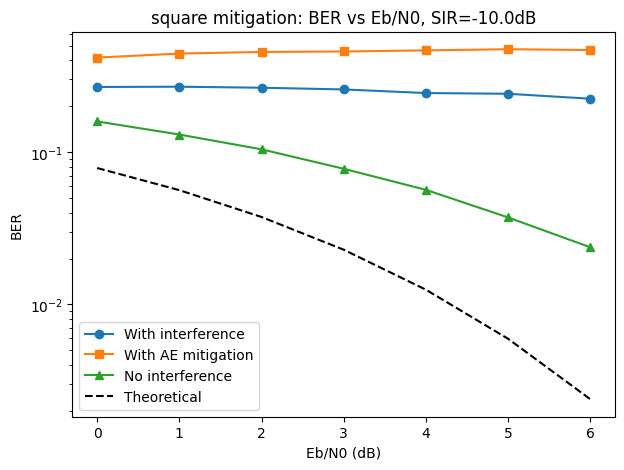

In [25]:
# Cell 10 — reusable interference-aware mitigation training + BER evaluation
def run_mitigation_experiment(interference_type, cfg, rng, device, n_symbols=1024,
                                snr_range=(-15, 30), sir_range=(-10, 30),
                                m_train=1500, m_val=400, sir_db_test=-10.0,
                                ebn0_range=(0,1,2,3,4,5,6), n_trials=100):
    print(f"\n{'='*20} {interference_type.upper()} {'='*20}")

    # Data
    X_train = np.stack([make_mitigation_pair(cfg, n_symbols, snr_range, sir_range, interference_type, rng)[0] for _ in range(m_train)])
    Y_train = np.stack([make_mitigation_pair(cfg, n_symbols, snr_range, sir_range, interference_type, rng)[1] for _ in range(m_train)])
    X_val = np.stack([make_mitigation_pair(cfg, n_symbols, snr_range, sir_range, interference_type, rng)[0] for _ in range(m_val)])
    Y_val = np.stack([make_mitigation_pair(cfg, n_symbols, snr_range, sir_range, interference_type, rng)[1] for _ in range(m_val)])
    identity_mse = np.mean((X_train - Y_train) ** 2)
    print(f"X_train: {X_train.shape}  Identity baseline MSE: {identity_mse:.4f}")

    # Quick sanity check (lighter than full debug ladder -- recipe already validated for tone)
    model = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
    tiny_out = model(torch.tensor(X_train[:8], device=device))
    tiny_loss = torch.nn.functional.mse_loss(tiny_out, torch.tensor(Y_train[:8], device=device)).item()
    print(f"Sanity check -- first-pass loss: {tiny_loss:.4f} (expect near identity baseline {identity_mse:.4f})")
    assert abs(tiny_loss - identity_mse) < identity_mse, "Loss far from identity baseline -- residual connection may not be active, STOP and investigate"

    # Training
    model = MitigationAutoencoder(n_stages=2, n_hidden=32)
    model, history = train_mitigation_ae(model, X_train, Y_train, X_val, Y_val, device,
                                           epochs=100, batch_size=32, lr=3e-5, patience=15)
    print(f"Final val_loss: {history['val_loss'][-1]:.4f}  (vs identity {identity_mse:.4f})")

    plt.figure(figsize=(6,4))
    plt.plot(history["train_loss"], label="train"); plt.plot(history["val_loss"], label="val")
    plt.title(f"{interference_type} mitigation AE training"); plt.legend()
    plt.savefig(f"figures/mitigation_ae_{interference_type}_training.png", dpi=150)
    plt.show()
    torch.save(model.state_dict(), f"checkpoints/mitigation_ae_{interference_type}.pt")

    # BER evaluation
    ber_rows = []
    for ebn0_db in ebn0_range:
        snr_db = ebn0_db - 10*np.log10(cfg.NSPS)
        ber_int, ber_mit, ber_clean = [], [], []
        for _ in range(n_trials):
            d = mix_signal(cfg, n_symbols, rng, interference_type=interference_type, contamination=1.0,
                            sir_db_range=(sir_db_test, sir_db_test), snr_db_range=(snr_db, snr_db), apply_shift=False)
            ber_int.append(matched_filter_ber(d["x"], d["bits"], cfg, n_symbols, d["fd"], d["phi_m"], d["k_shift"]))
            x_mit = ae_denoise(d["x"], model, device)
            ber_mit.append(matched_filter_ber(x_mit, d["bits"], cfg, n_symbols, d["fd"], d["phi_m"], d["k_shift"]))
            d_clean = mix_signal(cfg, n_symbols, rng, interference_type=interference_type, contamination=0.0,
                                  snr_db_range=(snr_db, snr_db), apply_shift=False)
            ber_clean.append(matched_filter_ber(d_clean["x"], d_clean["bits"], cfg, n_symbols, d_clean["fd"], d_clean["phi_m"], d_clean["k_shift"]))
        ber_rows.append({"ebn0_db": ebn0_db, "ber_with_interference": np.mean(ber_int),
                          "ber_mitigated": np.mean(ber_mit), "ber_no_interference": np.mean(ber_clean),
                          "ber_theoretical": theoretical_ber(ebn0_db)})
        print(f"Eb/N0={ebn0_db}dB  interference={np.mean(ber_int):.4f}  mitigated={np.mean(ber_mit):.4f}  clean={np.mean(ber_clean):.4f}")

    ber_df = pd.DataFrame(ber_rows)
    ber_df.to_csv(f"results/step8c_{interference_type}_mitigation_ber.csv", index=False)

    plt.figure(figsize=(7,5))
    plt.semilogy(ber_df["ebn0_db"], ber_df["ber_with_interference"], marker='o', label="With interference")
    plt.semilogy(ber_df["ebn0_db"], ber_df["ber_mitigated"], marker='s', label="With AE mitigation")
    plt.semilogy(ber_df["ebn0_db"], ber_df["ber_no_interference"], marker='^', label="No interference")
    plt.semilogy(ber_df["ebn0_db"], ber_df["ber_theoretical"], linestyle='--', color='black', label="Theoretical")
    plt.title(f"{interference_type} mitigation: BER vs Eb/N0, SIR={sir_db_test}dB")
    plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER"); plt.legend()
    plt.savefig(f"figures/step8c_{interference_type}_mitigation_ber.png", dpi=150)
    plt.show()

    return model, history, ber_df

# Run for SQUARE first
model_mit_square, history_mit_square, ber_df_square = run_mitigation_experiment("square", cfg, rng, device)


==================== CHIRP ====================
X_train: (1500, 2, 8192)  Identity baseline MSE: 2.7546
Sanity check -- first-pass loss: 1.6586 (expect near identity baseline 2.7546)
Epoch 1/100  train_loss=2.70474  val_loss=2.64363
Epoch 5/100  train_loss=2.11045  val_loss=2.11804
Epoch 10/100  train_loss=1.94619  val_loss=1.96755
Epoch 15/100  train_loss=1.83406  val_loss=1.84965
Epoch 20/100  train_loss=1.74492  val_loss=1.76371
Epoch 25/100  train_loss=1.68956  val_loss=1.69807
Epoch 30/100  train_loss=1.63444  val_loss=1.64487
Epoch 35/100  train_loss=1.58152  val_loss=1.59418
Epoch 40/100  train_loss=1.52426  val_loss=1.53970
Epoch 45/100  train_loss=1.45050  val_loss=1.46106
Epoch 50/100  train_loss=1.37992  val_loss=1.39046
Epoch 55/100  train_loss=1.31200  val_loss=1.33731
Epoch 60/100  train_loss=1.24608  val_loss=1.27129
Epoch 65/100  train_loss=1.18882  val_loss=1.21988
Epoch 70/100  train_loss=1.15269  val_loss=1.17175
Epoch 75/100  train_loss=1.07436  val_loss=1.09281
Ep

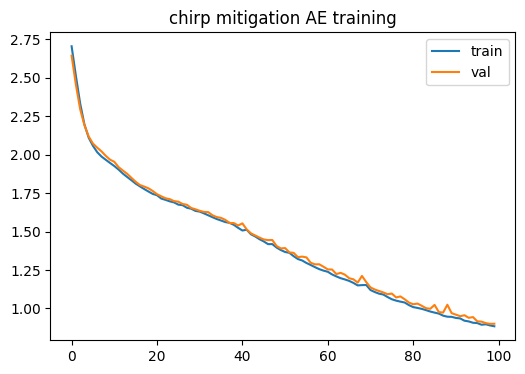

Eb/N0=0dB  interference=0.3686  mitigated=0.4136  clean=0.1590
Eb/N0=1dB  interference=0.3597  mitigated=0.4261  clean=0.1313
Eb/N0=2dB  interference=0.3624  mitigated=0.4399  clean=0.1044
Eb/N0=3dB  interference=0.3639  mitigated=0.4448  clean=0.0776
Eb/N0=4dB  interference=0.3694  mitigated=0.4467  clean=0.0564
Eb/N0=5dB  interference=0.3704  mitigated=0.4464  clean=0.0366
Eb/N0=6dB  interference=0.3575  mitigated=0.4410  clean=0.0229


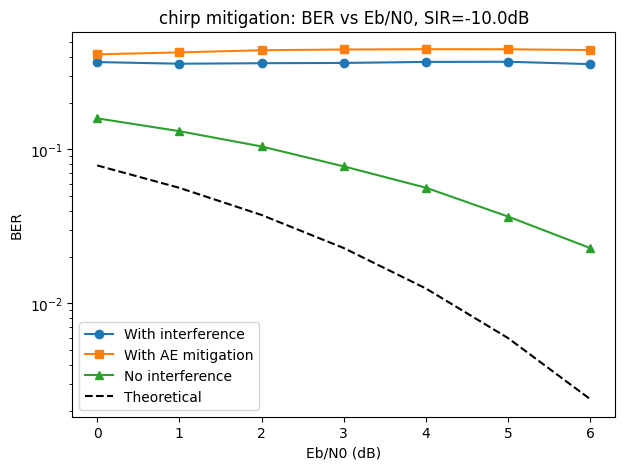

In [26]:
# Run for CHIRP
model_mit_chirp, history_mit_chirp, ber_df_chirp = run_mitigation_experiment("chirp", cfg, rng, device)